In [1]:
import os.path as op
import pickle
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler
from scipy.stats import spearmanr
import pandas as pd
from scipy.ndimage import gaussian_filter1d
import mne
from scipy import stats
from functools import partial

In [2]:
json_file = "settings.json"
with open(json_file) as pipeline_file:
    parameters = json.load(pipeline_file)
path = parameters["dataset_path"]

In [3]:
epoch_types=['STIM','RESP']
condition_names=['SHORT','LONG']

In [4]:
td_color=np.array([27,158,119])/255.0
asd_color=np.array([117,112,179])/255.0

In [5]:
all_bursts = {
    'subject_id': [],
    'group': [],
    'epoch_type': [],
    'condition': [],
    'cluster': [],
    'channel': [],
    'trial': [],
    'waveform': np.zeros((0, 156)),
    'waveform_times': [],
    'peak_freq': [],
    'peak_amp_iter': [],
    'peak_amp_base': [],
    'peak_time': [],
    'peak_adjustment': [],
    'fwhm_freq': [],
    'fwhm_time': [],
    'polarity': [],
}

all_beta_power={
    hemi: {        
        epo_type: {
            condition_name: [] for condition_name in condition_names
        } for epo_type in epoch_types
    } for hemi in ['ipsi','contra']
}
power_time=None

df = pd.read_csv(op.join(path, 'data_v2', 'GOGO_Demographics_2025_COMO.csv'))
for subject_id, group in df.loc[:, ["ParticipantID", "Status"]].itertuples(index=False, name=None):
    subject_data_dir=op.join('/home/common/bonaiuto/gogo_bursts/derivatives_v2/processed',subject_id)
    fname = op.join(subject_data_dir, f'{subject_id}_beta_power.npz')
    if op.exists(fname):
        data = np.load(fname, allow_pickle=True)
        subj_beta_power = data['all_beta_pow'].item()
        for hemi in ['ipsi','contra']:
            for epo_type in epoch_types:
                for condition_name in condition_names:
                    all_beta_power[hemi][epo_type][condition_name].append(np.mean(subj_beta_power[hemi][epo_type][condition_name],axis=0))
        power_time = data['time']

    fname = op.join(subject_data_dir, f'{subject_id}_bursts.pickle')
    if op.exists(fname):
        with open(fname,'rb') as file:
            bursts=pickle.load(file)
        for key in bursts.keys():
            if key=='waveform_times':
                all_bursts[key] = bursts[key]
            elif key=='waveform':
                all_bursts[key] = np.vstack([all_bursts[key], bursts[key]])
            else:
                all_bursts[key] = np.hstack([all_bursts[key], bursts[key]])
                
df = pd.read_csv(op.join(path, 'data_v2', 'GOGO_Demographics_2025_Driving.csv'))
for subject_id, group in df.loc[:, ["ParticipantID", "Status"]].itertuples(index=False, name=None):
    subject_data_dir=op.join('/home/common/bonaiuto/gogo_bursts/derivatives_v2/processed',subject_id)
    fname = op.join(subject_data_dir, f'{subject_id}_beta_power.npz')
    if op.exists(fname):
        data = np.load(fname, allow_pickle=True)
        subj_beta_power = data['all_beta_pow'].item()
        for hemi in ['ipsi','contra']:
            for epo_type in epoch_types:
                for condition_name in condition_names:
                    all_beta_power[hemi][epo_type][condition_name].append(np.mean(subj_beta_power[hemi][epo_type][condition_name],axis=0))
        power_time = data['time']

    fname = op.join(subject_data_dir, f'{subject_id}_bursts.pickle')
    if op.exists(fname):
        with open(fname,'rb') as file:
            bursts=pickle.load(file)
        for key in bursts.keys():
            if key=='waveform_times':
                all_bursts[key] = bursts[key]
            elif key=='waveform':
                all_bursts[key] = np.vstack([all_bursts[key], bursts[key]])
            else:
                all_bursts[key] = np.hstack([all_bursts[key], bursts[key]])

In [6]:
burst_idx = (all_bursts['group']=='TD') & (all_bursts['cluster']=='contra')

In [7]:
for key in all_bursts.keys():
    if key=='waveform_times':
        continue
    elif key=='waveform':
        all_bursts[key] = all_bursts[key][burst_idx,:]
    else:
        all_bursts[key] = all_bursts[key][burst_idx]

In [8]:
stim_idx = all_bursts['epoch_type']=='STIM'
resp_idx = all_bursts['epoch_type']=='RESP'

In [9]:
waveform_times=all_bursts['waveform_times']

In [22]:
n=len(np.unique(all_bursts['subject_id']))
print(f'N subjects={n}')

subject_ids=np.unique(all_bursts['subject_id'])

N subjects=33


In [35]:
def shuffle_array(array):
    X_array = array.copy()
    rows, columns = array.shape
    for col in range(columns):
        ixes = np.arange(0,rows)
        np.random.shuffle(ixes)
        X_array[:,col] = X_array[:,col][ixes]
    return X_array

def shuffle_array_range(array, ranges):
    X_array = []
    for x1, x2 in ranges:
        X = wvf[:,x1:x2]
        np.random.shuffle(X)
        X_array.append(X)
    return np.hstack(X_array)

def get_num_components(waveforms, n_comps):
    # robust scaling
#     waveforms_scaled = RobustScaler().fit_transform(waveforms)
    waveforms_scaled=np.zeros(waveforms.shape)
    for subject in np.unique(all_bursts['subject_id']):
        s_idx=all_bursts['subject_id']==subject
        waveforms_scaled[s_idx,:] = RobustScaler().fit_transform(waveforms[s_idx,:])
    waveforms_scaled = RobustScaler().fit_transform(waveforms_scaled)


    # main PCA fitting
    pca_full = PCA(n_components=n_comps)
    pcs_full = pca_full.fit_transform(waveforms_scaled)
    var_full = pca_full.explained_variance_ratio_ 

    # robustness of pca components
    no_of_iter = 100
    pca_vars = []
    for i in range(no_of_iter):
        shuffled_wvf = shuffle_array(waveforms_scaled)

        pca_shuff = PCA(n_components=n_comps)
        pca_shuff.fit(shuffled_wvf)
        pca_vars.append(pca_shuff.explained_variance_ratio_)        
    del shuffled_wvf
    pca_vars=np.array(pca_vars)

    # getting the magic number
    results = np.sum(var_full>pca_vars, axis=0) / no_of_iter
    threshold=1-(.05/n_comps)
    PCS_to_analyse = np.where(results > threshold)[0]
    return PCS_to_analyse

shuffling_results=get_num_components(all_bursts['waveform'], 20)
print(f'Non-noise PCs: {shuffling_results}')

Non-noise PCs: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]


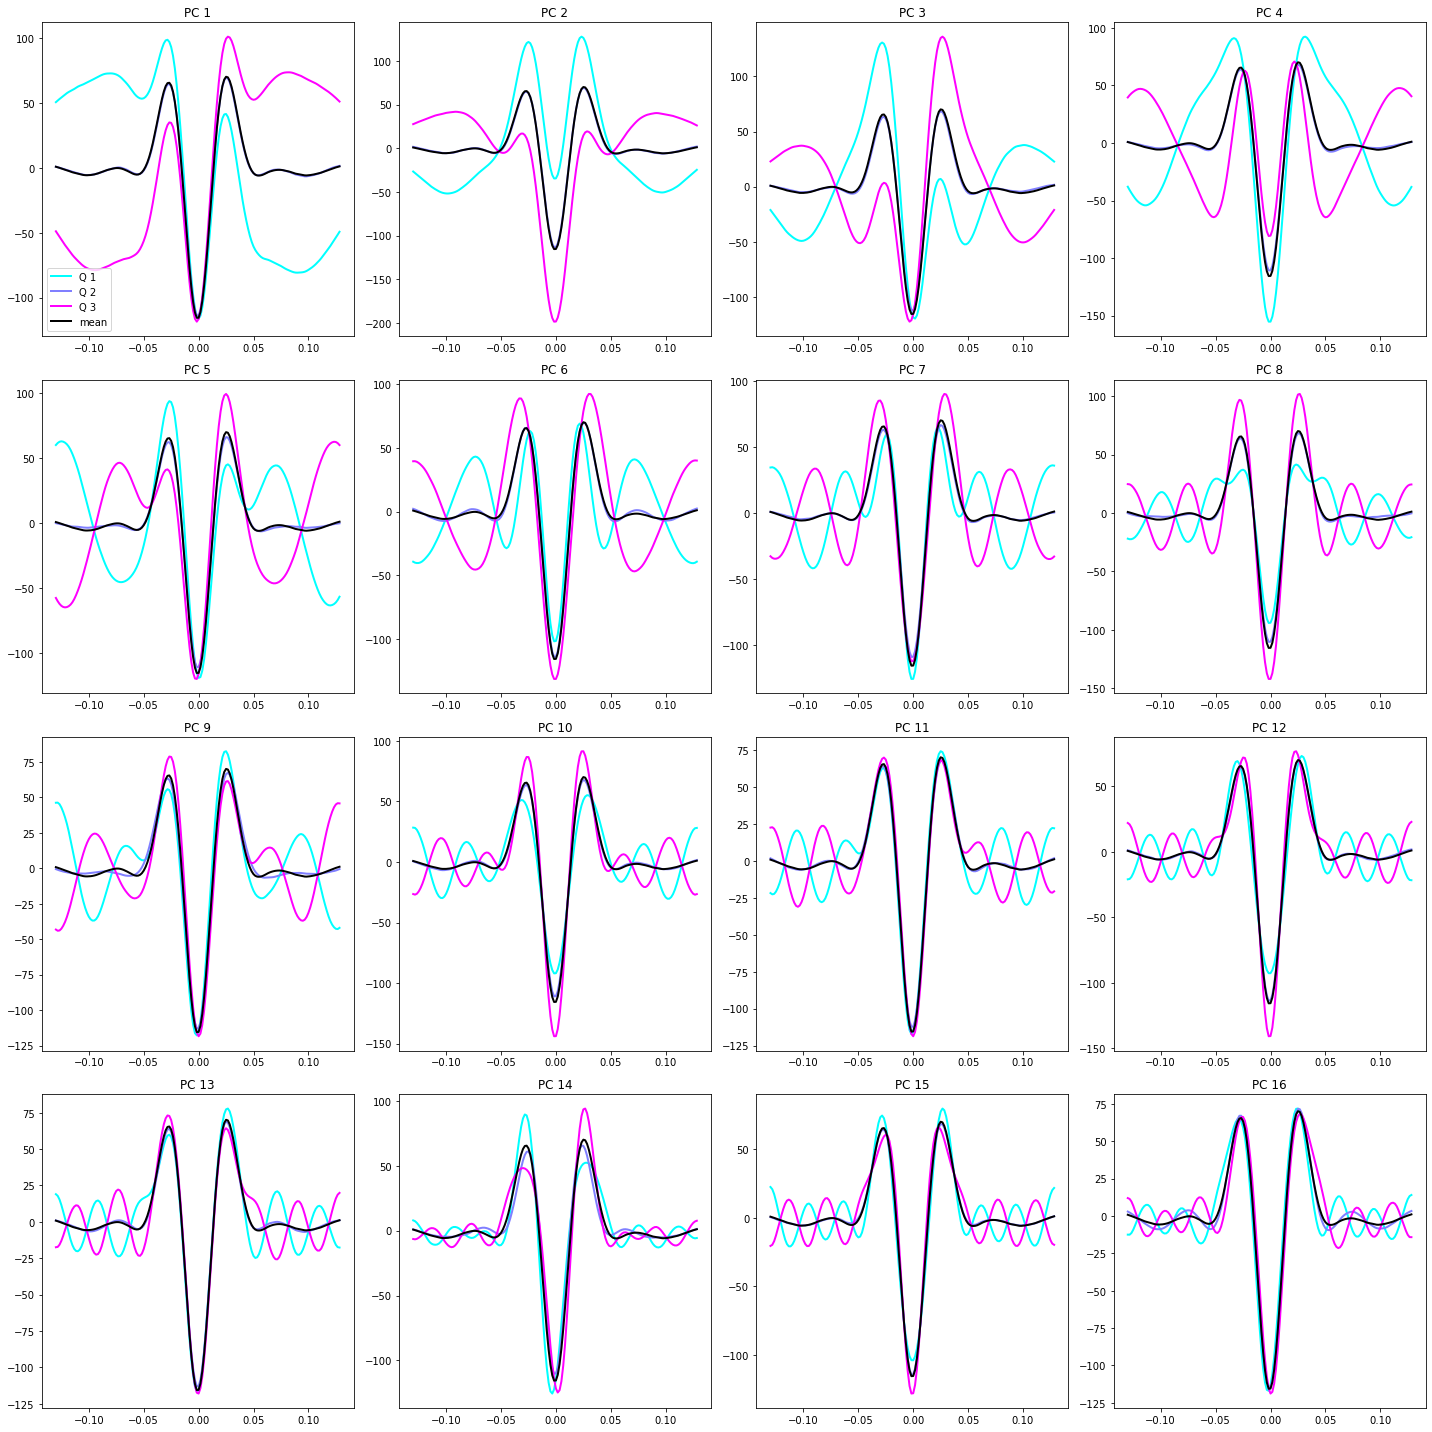

In [36]:
waveforms=all_bursts['waveform']
model = PCA(n_components=20)
burst_std=np.zeros(waveforms.shape)
for subject in np.unique(all_bursts['subject_id']):
    s_idx=all_bursts['subject_id']==subject
    burst_std[s_idx,:] = RobustScaler().fit_transform(waveforms[s_idx,:])
burst_std = RobustScaler().fit_transform(burst_std)
model.fit(burst_std)
pc_scores = model.transform(burst_std)  # all the bursts x 20 components
pc_labels = ["PC_{}".format(i+1) for i in range(pc_scores.shape[1])]

n_q=3
quartiles = np.linspace(0, 100, num=n_q+1)
quartiles = list(zip(quartiles[:-1], quartiles[1:]))
col_range = plt.cm.cool(np.linspace(0, 1, num=len(quartiles)))
mean_waveform = np.mean(waveforms, axis=0)

f, ax = plt.subplots(4, 4, figsize=(20, 20))
ax = ax.flatten()
for pc_ix, pc in enumerate(pc_labels[:len(shuffling_results)]):
    ax[pc_ix].set_title(pc.replace("_", " "))  # set the nice title
    scores = pc_scores[:,pc_ix]
    q_maps = []
    for q_ix, (b, e) in enumerate(quartiles):
        q_map = (scores > np.percentile(scores, b)) & (scores <= np.percentile(scores, e))  # create a boolean map to select the waveforms
        q_mean = np.mean(waveforms[q_map], axis=0)
        ax[pc_ix].plot(waveform_times, q_mean/1e-15, lw=2, c=col_range[q_ix], label="Q {}".format(q_ix+1))
    ax[pc_ix].plot(waveform_times, mean_waveform/1e-15, lw=2, c="black", label="mean")
ax[0].legend(fontsize=10)

plt.tight_layout()
plt.show()

In [37]:
df_dict={}
for key in all_bursts:
    if not (key=='waveform' or key=='waveform_times'):
        df_dict[key]=all_bursts[key]

for pc_idx in range(20):
    df_dict[pc_labels[pc_idx]]=pc_scores[:,pc_idx]
all_bursts_df = pd.DataFrame(df_dict)
all_bursts_df.to_csv('/home/common/bonaiuto/gogo_bursts/derivatives_v2/processed/output/TD_contra_burst_features.csv', index=False)

In [38]:
bin_width = 0.025
stim_time_bins = np.arange(-1.75, 1.75, bin_width)
resp_time_bins = np.arange(-1.75, 1.75, bin_width)

subject_score_ts={
    epoch_type: {
        condition: [] for condition in condition_names
    } for epoch_type in epoch_types
}
for subject_id in subject_ids:
    for epoch_type in epoch_types:
        for condition in condition_names:
            b_idx=(all_bursts['subject_id']==subject_id) & (all_bursts['epoch_type']==epoch_type) & (all_bursts['condition']==condition)
            pc_score_ts=[]
            for t_idx in range(len(stim_time_bins)-1):
                st=stim_time_bins[t_idx]
                en=stim_time_bins[t_idx+1]
                bb_idx=b_idx & (all_bursts['peak_time']>=st) & (all_bursts['peak_time']<=en)
                ms=np.nanmean(pc_scores[bb_idx,:],axis=0)
                pc_score_ts.append(ms)
            pc_score_ts=np.array(pc_score_ts)
            pc_score_ts = gaussian_filter1d(pc_score_ts, sigma=2.5, axis=0, mode="nearest")
            subject_score_ts[epoch_type][condition].append(pc_score_ts)

for epoch_type in epoch_types:
    for condition in condition_names:
        subject_score_ts[epoch_type][condition]=np.array(subject_score_ts[epoch_type][condition])

PC8 SHORT p=0.007099290070992901
PC8 LONG p=9.999000099990002e-05


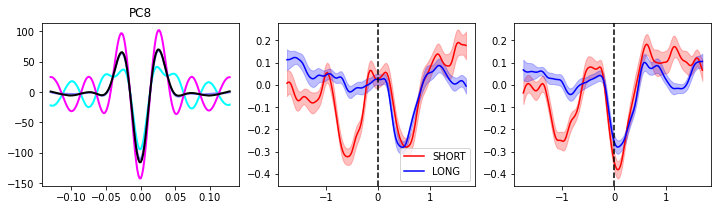

PC10 SHORT p=0.0022997700229977
PC10 LONG p=9.999000099990002e-05


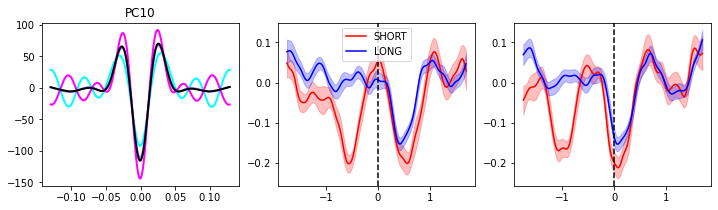

PC12 SHORT p=0.004199580041995801
PC12 LONG p=0.00039996000399960006


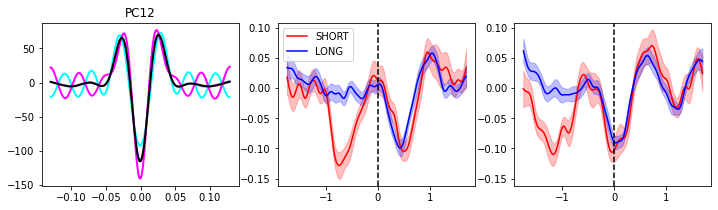

In [39]:
n_perm = 10000  # number of permutations

# Boolean mask for STIM baseline (pre-0)
stim_baseline_mask = (stim_time_bins[:-1] > -1.5) & (stim_time_bins[:-1] < -1)
resp_mask = (resp_time_bins[:-1] > -.25) & (resp_time_bins[:-1] < .5)

task_pcs=[]

for pc in shuffling_results:
    m_stim_short = np.nanmean(subject_score_ts['STIM']['SHORT'], axis=0)[:, pc]
    se_stim_short = np.nanstd(subject_score_ts['STIM']['SHORT'], axis=0)[:, pc]/np.sqrt(subject_score_ts['STIM']['SHORT'].shape[0])
    m_resp_short = np.nanmean(subject_score_ts['RESP']['SHORT'], axis=0)[:, pc]
    se_resp_short = np.nanstd(subject_score_ts['RESP']['SHORT'], axis=0)[:, pc]/np.sqrt(subject_score_ts['RESP']['SHORT'].shape[0])
    
    m_stim_long = np.nanmean(subject_score_ts['STIM']['LONG'], axis=0)[:, pc]
    se_stim_long = np.nanstd(subject_score_ts['STIM']['LONG'], axis=0)[:, pc]/np.sqrt(subject_score_ts['STIM']['LONG'].shape[0])
    m_resp_long = np.nanmean(subject_score_ts['RESP']['LONG'], axis=0)[:, pc]
    se_resp_long = np.nanstd(subject_score_ts['RESP']['LONG'], axis=0)[:, pc]/np.sqrt(subject_score_ts['RESP']['LONG'].shape[0])
    
    # ------------------------------------------------------------------
    # Permutation test: is RESP temporal variance > STIM pre-0 variance?
    # ------------------------------------------------------------------
    stim_data_short = subject_score_ts['STIM']['SHORT'][:, :, pc]  # shape: n_subj × n_time_stim
    resp_data_short = subject_score_ts['RESP']['SHORT'][:, :, pc]  # shape: n_subj × n_time_resp
    stim_data_long = subject_score_ts['STIM']['LONG'][:, :, pc]  # shape: n_subj × n_time_stim
    resp_data_long = subject_score_ts['RESP']['LONG'][:, :, pc]  # shape: n_subj × n_time_resp

    # Per-subject temporal variances
    var_baseline_short = np.nanvar(stim_data_short[:, stim_baseline_mask], axis=1, ddof=1)
    var_resp_short = np.nanvar(resp_data_short[:, resp_mask], axis=1, ddof=1)
    var_baseline_long = np.nanvar(stim_data_long[:, stim_baseline_mask], axis=1, ddof=1)
    var_resp_long = np.nanvar(resp_data_long[:, resp_mask], axis=1, ddof=1)

    diff_short = var_resp_short - var_baseline_short              # ?_i
    diff_long = var_resp_long - var_baseline_long              # ?_i
    obs_stat_short = np.mean(diff_short)                    # observed mean difference across subjects
    obs_stat_long = np.mean(diff_long)                    # observed mean difference across subjects

    # Sign-flip permutation for paired test
    null_stats_short = np.zeros(n_perm)
    null_stats_long = np.zeros(n_perm)
    for p in range(n_perm):
        signs_short = np.random.choice([1, -1], size=diff_short.shape[0])
        signs_long = np.random.choice([1, -1], size=diff_long.shape[0])
        null_stats_short[p] = np.mean(diff_short * signs_short)
        null_stats_long[p] = np.mean(diff_long * signs_long)

    # One-sided p-value: H1 = RESP variance > baseline variance
    p_val_short = (np.sum(null_stats_short >= obs_stat_short) + 1) / (n_perm + 1)
    p_val_long = (np.sum(null_stats_long >= obs_stat_long) + 1) / (n_perm + 1)
    
    if p_val_short*len(shuffling_results)<0.05 or p_val_long*len(shuffling_results)<0.05:
        print(f'PC{pc+1} SHORT p={p_val_short}')
        print(f'PC{pc+1} LONG p={p_val_long}')
        task_pcs.append(pc)
        
        plt.figure(figsize=(12,3))

        ax=plt.subplot(1,3,1)
        ax.set_title(f'PC{pc+1}')  # set the nice title
        scores = pc_scores[:,pc]
        q_maps = []
        for q_ix, (b, e) in enumerate(quartiles):
            q_map = (scores > np.percentile(scores, b)) & (scores <= np.percentile(scores, e))  # create a boolean map to select the waveforms
            q_mean = np.mean(waveforms[q_map], axis=0)
            ax.plot(waveform_times, q_mean/1e-15, lw=2, c=col_range[q_ix], label="Q {}".format(q_ix+1))
        ax.plot(waveform_times, mean_waveform/1e-15, lw=2, c="black", label="mean")

        # STIM
        ax1 = plt.subplot(1,3,2)
        ax1.plot(stim_time_bins[:-1], m_stim_short, color='r', label='SHORT')
        ax1.fill_between(stim_time_bins[:-1], m_stim_short-se_stim_short, m_stim_short+se_stim_short, color='r', alpha=0.25)
        ax1.plot(stim_time_bins[:-1], m_stim_long, color='b', label='LONG')
        ax1.fill_between(stim_time_bins[:-1], m_stim_long-se_stim_long, m_stim_long+se_stim_long, color='b', alpha=0.25)
        ax1.axvline(0,color='k',linestyle='--')
        ax1.legend()
        yl1=ax1.get_ylim()

        # RESP
        ax2 = plt.subplot(1,3,3)
        ax2.plot(resp_time_bins[:-1], m_resp_short, color='r')
        ax2.fill_between(resp_time_bins[:-1], m_resp_short-se_resp_short, m_resp_short+se_resp_short, color='r', alpha=0.25)
        ax2.plot(resp_time_bins[:-1], m_resp_long, color='b')
        ax2.fill_between(resp_time_bins[:-1], m_resp_long-se_resp_long, m_resp_long+se_resp_long, color='b', alpha=0.25)
        ax2.axvline(0,color='k',linestyle='--')
        yl2=ax2.get_ylim()

        ymin=np.min([yl1[0], yl2[0]])
        ymax=np.max([yl1[1], yl2[1]])
        ax1.set_ylim(ymin, ymax)
        ax2.set_ylim(ymin, ymax)
        plt.show()

stat_fun(H1): min=-2.312981 max=3.633315
Running initial clustering …
Using 727 thresholds from 0.00 to 3.63 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-1.269905 max=3.986118
Running initial clustering …
Using 798 thresholds from 0.00 to 3.98 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-7.333097 max=3.185488
Running initial clustering …
Using 1467 thresholds from 0.00 to 7.33 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-1.434866 max=5.655723
Running initial clustering …
Using 1132 thresholds from 0.00 to 5.66 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-9.030976 max=1.855003
Running initial clustering …
Using 1807 thresholds from 0.00 to 9.03 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

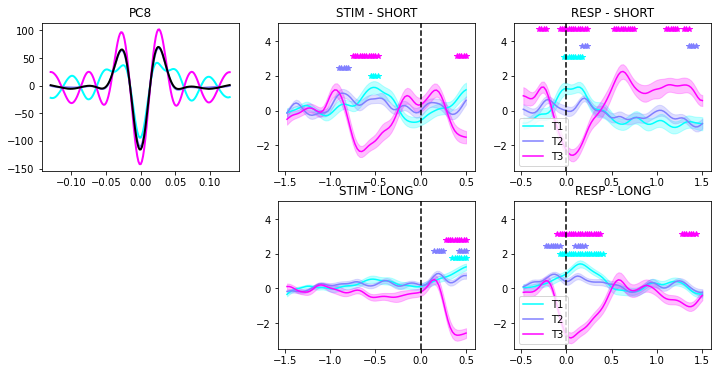

stat_fun(H1): min=-2.930057 max=4.090068
Running initial clustering …
Using 819 thresholds from 0.00 to 4.09 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-1.898233 max=3.466270
Running initial clustering …
Using 694 thresholds from 0.00 to 3.46 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-5.644688 max=2.643511
Running initial clustering …
Using 1129 thresholds from 0.00 to 5.64 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.214682 max=4.648490
Running initial clustering …
Using 930 thresholds from 0.00 to 4.65 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-9.283446 max=2.869553
Running initial clustering …
Using 1857 thresholds from 0.00 to 9.28 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

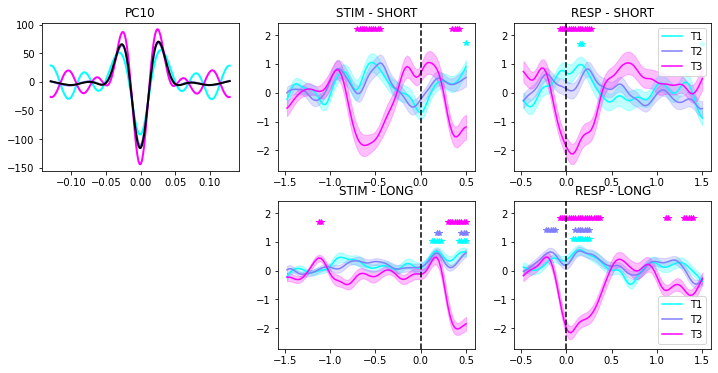

stat_fun(H1): min=-1.122402 max=6.224539
Running initial clustering …
Using 1245 thresholds from 0.00 to 6.22 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-1.883168 max=4.579768
Running initial clustering …
Using 916 thresholds from 0.00 to 4.58 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-6.899739 max=1.879469
Running initial clustering …
Using 1380 thresholds from 0.00 to 6.90 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.374052 max=5.053983
Running initial clustering …
Using 1011 thresholds from 0.00 to 5.05 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-7.267693 max=2.697798
Running initial clustering …
Using 1454 thresholds from 0.00 to 7.27 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

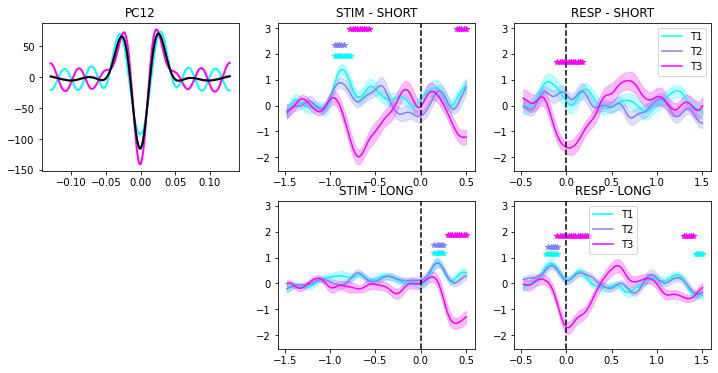

In [41]:
step = 100 / n_q
stim_plt_idx=(stim_time_bins[:-1]>=-1.5) & (stim_time_bins[:-1]<=.5)
resp_plt_idx=(resp_time_bins[:-1]>=-.5) & (resp_time_bins[:-1]<=1.5)

stim_time_plt=stim_time_bins[:-1][stim_plt_idx]
resp_time_plt=resp_time_bins[:-1][resp_plt_idx]

threshold_tfce = dict(start=0, step=0.005)

for pc in task_pcs:
    q_bins = np.percentile(pc_scores[:, pc], np.arange(0, 100 + step, step))

    q_rates_smoothed = {
        q: {
            epoch_type: {
                condition: [] for condition in condition_names
            } for epoch_type in epoch_types
        } for q in range(n_q)
    }
    for subject_id in subject_ids:
        subj_idx = (all_bursts['subject_id'] == subject_id)

        stim_b_idx=(all_bursts['subject_id']==subject_id) & stim_idx
        resp_b_idx=(all_bursts['subject_id']==subject_id) & resp_idx

        for q in range(n_q):
            q_idx = ((pc_scores[:, pc] >= q_bins[q]) &
                     (pc_scores[:, pc] <= q_bins[q+1]))
            
            stim_short_idx = stim_b_idx & (all_bursts['condition']=='SHORT')
            resp_short_idx = resp_b_idx & (all_bursts['condition']=='SHORT')
            stim_long_idx = stim_b_idx & (all_bursts['condition']=='LONG')
            resp_long_idx = resp_b_idx & (all_bursts['condition']=='LONG')
            
            stim_short_trials = np.unique(all_bursts['trial'][stim_short_idx])
            resp_short_trials = np.unique(all_bursts['trial'][resp_short_idx])
            stim_long_trials = np.unique(all_bursts['trial'][stim_long_idx])
            resp_long_trials = np.unique(all_bursts['trial'][resp_long_idx])

            stim_short_unsmoothed_rate, _ = np.histogram(
                all_bursts['peak_time'][subj_idx & stim_short_idx & q_idx],
                bins=stim_time_bins
            )
            resp_short_unsmoothed_rate, _ = np.histogram(
                all_bursts['peak_time'][subj_idx & resp_short_idx & q_idx],
                bins=resp_time_bins
            )
            stim_long_unsmoothed_rate, _ = np.histogram(
                all_bursts['peak_time'][subj_idx & stim_long_idx & q_idx],
                bins=stim_time_bins
            )
            resp_long_unsmoothed_rate, _ = np.histogram(
                all_bursts['peak_time'][subj_idx & resp_long_idx & q_idx],
                bins=resp_time_bins
            )

            # Convert to rate
            stim_short_unsmoothed_rate = (stim_short_unsmoothed_rate / bin_width) / len(stim_short_trials)
            resp_short_unsmoothed_rate = (resp_short_unsmoothed_rate / bin_width) / len(resp_short_trials)
            stim_long_unsmoothed_rate = (stim_long_unsmoothed_rate / bin_width) / len(stim_long_trials)
            resp_long_unsmoothed_rate = (resp_long_unsmoothed_rate / bin_width) / len(resp_long_trials)

            stim_short_smoothed_rate = gaussian_filter1d(stim_short_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")
            resp_short_smoothed_rate = gaussian_filter1d(resp_short_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")
            stim_long_smoothed_rate = gaussian_filter1d(stim_long_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")
            resp_long_smoothed_rate = gaussian_filter1d(resp_long_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")

            base_idx = np.where((stim_time_bins>=-1.5) & (stim_time_bins < -1))[0]
            
            base_rate = np.mean(stim_short_smoothed_rate[base_idx])
            stim_short_smoothed_rate = (stim_short_smoothed_rate - base_rate)[stim_plt_idx]
            resp_short_smoothed_rate = (resp_short_smoothed_rate - base_rate)[resp_plt_idx]
            base_rate = np.mean(stim_long_smoothed_rate[base_idx])
            stim_long_smoothed_rate = (stim_long_smoothed_rate - base_rate)[stim_plt_idx]
            resp_long_smoothed_rate = (resp_long_smoothed_rate - base_rate)[resp_plt_idx]

            q_rates_smoothed[q]['STIM']['SHORT'].append(stim_short_smoothed_rate)
            q_rates_smoothed[q]['RESP']['SHORT'].append(resp_short_smoothed_rate)
            q_rates_smoothed[q]['STIM']['LONG'].append(stim_long_smoothed_rate)
            q_rates_smoothed[q]['RESP']['LONG'].append(resp_long_smoothed_rate)
            
    plt.figure(figsize=(12,6))

    ax=plt.subplot(2,3,1)
    ax.set_title(f'PC{pc+1}')  # set the nice title
    scores = pc_scores[:,pc]
    q_maps = []
    for q_ix, (b, e) in enumerate(quartiles):
        q_map = (scores > np.percentile(scores, b)) & (scores <= np.percentile(scores, e))  # create a boolean map to select the waveforms
        q_mean = np.mean(waveforms[q_map], axis=0)
        ax.plot(waveform_times, q_mean/1e-15, lw=2, c=col_range[q_ix], label="Q {}".format(q_ix+1))
    ax.plot(waveform_times, mean_waveform/1e-15, lw=2, c="black", label="mean")

    # STIM
    ax1 = plt.subplot(2,3,2)
    for q in range(n_q):
        m_rate=np.mean(q_rates_smoothed[q]['STIM']['SHORT'],axis=0)
        se_rate=np.std(q_rates_smoothed[q]['STIM']['SHORT'],axis=0)/np.sqrt(len(q_rates_smoothed[q]['STIM']['SHORT']))
        ax1.plot(stim_time_plt, m_rate, color=col_range[q])
        ax1.fill_between(stim_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])
        
    for q in range(n_q):
        stim_data = np.array(q_rates_smoothed[q]['STIM']['SHORT'])
        stim_T_obs, stim_clusters, stim_cluster_p_values, H0 = mne.stats.permutation_cluster_1samp_test(
            stim_data,
            threshold=threshold_tfce,
            n_permutations=1000,
            tail=0,
            n_jobs=-1
        )
        # Plot significant clusters
        yl = ax1.get_ylim()
        py = yl[1] + (q+1)*.05 * (yl[1] - 0)
        for p_idx, p_val in enumerate(stim_cluster_p_values):
            if p_val < 0.05:
                ax1.plot(stim_time_plt[p_idx], py, '*', color=col_range[q])
    ax1.set_title('STIM - SHORT')         
    ax1.axvline(0,color='k',linestyle='--')
    yl1=ax1.get_ylim()

    # RESP
    ax2 = plt.subplot(2,3,3)
    for q in range(n_q):
        m_rate=np.mean(q_rates_smoothed[q]['RESP']['SHORT'],axis=0)
        se_rate=np.std(q_rates_smoothed[q]['RESP']['SHORT'],axis=0)/np.sqrt(len(q_rates_smoothed[q]['RESP']['SHORT']))
        ax2.plot(resp_time_plt, m_rate, color=col_range[q], label=f'T{q+1}')
        ax2.fill_between(resp_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])
        
    for q in range(n_q):
        resp_data = np.array(q_rates_smoothed[q]['RESP']['SHORT'])
        resp_T_obs, resp_clusters, resp_cluster_p_values, H0 = mne.stats.permutation_cluster_1samp_test(
            resp_data,
            threshold=threshold_tfce,
            n_permutations=1000,
            tail=0,
            n_jobs=-1
        )
        # Plot significant clusters
        yl = ax2.get_ylim()
        py = yl[1] + (q+1)*.05 * (yl[1] - 0)
        for p_idx, p_val in enumerate(resp_cluster_p_values):
            if p_val < 0.05:
                ax2.plot(resp_time_plt[p_idx], py, '*', color=col_range[q])
                
    ax2.legend()
    ax2.set_title('RESP - SHORT')
    ax2.axvline(0,color='k',linestyle='--')
    yl2=ax2.get_ylim()
    
    # STIM
    ax3 = plt.subplot(2,3,5)
    for q in range(n_q):
        m_rate=np.mean(q_rates_smoothed[q]['STIM']['LONG'],axis=0)
        se_rate=np.std(q_rates_smoothed[q]['STIM']['LONG'],axis=0)/np.sqrt(len(q_rates_smoothed[q]['STIM']['LONG']))
        ax3.plot(stim_time_plt, m_rate, color=col_range[q])
        ax3.fill_between(stim_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])
        
    for q in range(n_q):
        stim_data = np.array(q_rates_smoothed[q]['STIM']['LONG'])
        stim_T_obs, stim_clusters, stim_cluster_p_values, H0 = mne.stats.permutation_cluster_1samp_test(
            stim_data,
            threshold=threshold_tfce,
            n_permutations=1000,
            tail=0,
            n_jobs=-1
        )
        # Plot significant clusters
        yl = ax3.get_ylim()
        py = yl[1] + (q+1)*.05 * (yl[1] - 0)
        for p_idx, p_val in enumerate(stim_cluster_p_values):
            if p_val < 0.05:
                ax3.plot(stim_time_plt[p_idx], py, '*', color=col_range[q])
    ax3.set_title('STIM - LONG')         
    ax3.axvline(0,color='k',linestyle='--')
    yl3=ax3.get_ylim()

    # RESP
    ax4 = plt.subplot(2,3,6)
    for q in range(n_q):
        m_rate=np.mean(q_rates_smoothed[q]['RESP']['LONG'],axis=0)
        se_rate=np.std(q_rates_smoothed[q]['RESP']['LONG'],axis=0)/np.sqrt(len(q_rates_smoothed[q]['RESP']['LONG']))
        ax4.plot(resp_time_plt, m_rate, color=col_range[q], label=f'T{q+1}')
        ax4.fill_between(resp_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])
        
    for q in range(n_q):
        resp_data = np.array(q_rates_smoothed[q]['RESP']['LONG'])
        resp_T_obs, resp_clusters, resp_cluster_p_values, H0 = mne.stats.permutation_cluster_1samp_test(
            resp_data,
            threshold=threshold_tfce,
            n_permutations=1000,
            tail=0,
            n_jobs=-1
        )
        # Plot significant clusters
        yl = ax4.get_ylim()
        py = yl[1] + (q+1)*.05 * (yl[1] - 0)
        for p_idx, p_val in enumerate(resp_cluster_p_values):
            if p_val < 0.05:
                ax4.plot(resp_time_plt[p_idx], py, '*', color=col_range[q])
                
    ax4.legend()
    ax4.set_title('RESP - LONG')
    ax4.axvline(0,color='k',linestyle='--')
    yl4=ax4.get_ylim()

    ymin=np.min([yl1[0], yl2[0], yl3[0], yl4[0]])
    ymax=np.max([yl1[1], yl2[1], yl3[0], yl4[0]])
    ax1.set_ylim(ymin, ymax)
    ax2.set_ylim(ymin, ymax)
    ax3.set_ylim(ymin, ymax)
    ax4.set_ylim(ymin, ymax)
    plt.show()

stat_fun(H1): min=-1.788132 max=1.990860
Running initial clustering …
Using 399 thresholds from 0.00 to 1.99 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-1.203337 max=3.067925
Running initial clustering …
Using 614 thresholds from 0.00 to 3.06 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.609886 max=2.199484
Running initial clustering …
Using 522 thresholds from 0.00 to 2.60 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.557024 max=5.798709
Running initial clustering …
Using 1160 thresholds from 0.00 to 5.79 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-5.180958 max=0.047683
Running initial clustering …
Using 1037 thresholds from 0.00 to 5.18 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

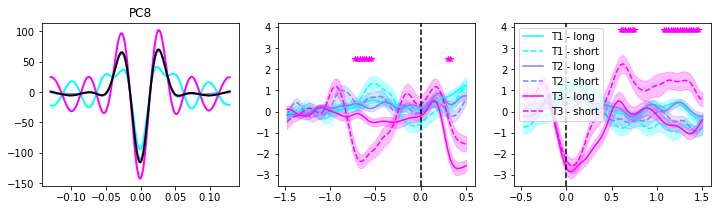

stat_fun(H1): min=-2.667744 max=2.583167
Running initial clustering …
Using 534 thresholds from 0.00 to 2.67 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-1.434625 max=1.668753
Running initial clustering …
Using 334 thresholds from 0.00 to 1.67 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.276725 max=1.814692
Running initial clustering …
Using 456 thresholds from 0.00 to 2.27 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.752781 max=4.718753
Running initial clustering …
Using 944 thresholds from 0.00 to 4.71 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.039584 max=1.317237
Running initial clustering …
Using 608 thresholds from 0.00 to 3.04 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

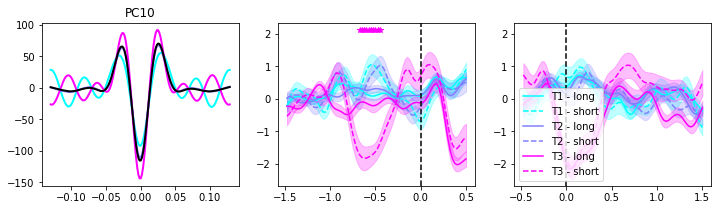

stat_fun(H1): min=-4.370859 max=1.276734
Running initial clustering …
Using 875 thresholds from 0.00 to 4.37 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-1.894179 max=1.230973
Running initial clustering …
Using 379 thresholds from 0.00 to 1.89 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.723528 max=1.869847
Running initial clustering …
Using 745 thresholds from 0.00 to 3.72 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.763881 max=5.115768
Running initial clustering …
Using 1024 thresholds from 0.00 to 5.12 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.281443 max=1.079322
Running initial clustering …
Using 457 thresholds from 0.00 to 2.28 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

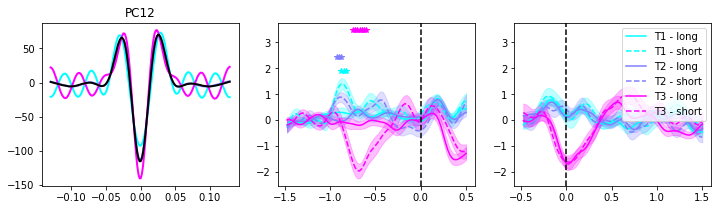

In [42]:
step = 100 / n_q

# Define custom paired t-test function (returns t-values only, no p-values)
def ttest_rel_no_p(x, y, axis=0):
    tvals, _ = stats.ttest_rel(x, y, axis=axis, nan_policy='omit')
    return tvals

paired_t = partial(ttest_rel_no_p, axis=0)
threshold_tfce = dict(start=0, step=0.005)


for pc in task_pcs:
    q_bins = np.percentile(pc_scores[:, pc], np.arange(0, 100 + step, step))

    q_rates_smoothed = {q: {epoch_type: {condition: [] for condition in condition_names} for epoch_type in epoch_types} for q in range(n_q)}
    for subject_id in subject_ids:
        subj_idx = (all_bursts['subject_id'] == subject_id)

        long_stim_b_idx=(all_bursts['subject_id']==subject_id) & stim_idx & (all_bursts['condition']=='LONG')
        short_stim_b_idx=(all_bursts['subject_id']==subject_id) & stim_idx & (all_bursts['condition']=='SHORT')
        long_resp_b_idx=(all_bursts['subject_id']==subject_id) & resp_idx & (all_bursts['condition']=='LONG')
        short_resp_b_idx=(all_bursts['subject_id']==subject_id) & resp_idx & (all_bursts['condition']=='SHORT')

        for q in range(n_q):
            q_idx = ((pc_scores[:, pc] >= q_bins[q]) &
                     (pc_scores[:, pc] <= q_bins[q+1]))
            long_stim_trials = np.unique(all_bursts['trial'][long_stim_b_idx])
            short_stim_trials = np.unique(all_bursts['trial'][short_stim_b_idx])
            long_resp_trials = np.unique(all_bursts['trial'][long_resp_b_idx])
            short_resp_trials = np.unique(all_bursts['trial'][short_resp_b_idx])

            long_stim_unsmoothed_rate, _ = np.histogram(
                all_bursts['peak_time'][subj_idx & long_stim_b_idx & q_idx],
                bins=stim_time_bins
            )
            short_stim_unsmoothed_rate, _ = np.histogram(
                all_bursts['peak_time'][subj_idx & short_stim_b_idx & q_idx],
                bins=stim_time_bins
            )
            long_resp_unsmoothed_rate, _ = np.histogram(
                all_bursts['peak_time'][subj_idx & long_resp_b_idx & q_idx],
                bins=resp_time_bins
            )
            short_resp_unsmoothed_rate, _ = np.histogram(
                all_bursts['peak_time'][subj_idx & short_resp_b_idx & q_idx],
                bins=resp_time_bins
            )

            # Convert to rate
            long_stim_unsmoothed_rate = (long_stim_unsmoothed_rate / bin_width) / len(long_stim_trials)
            short_stim_unsmoothed_rate = (short_stim_unsmoothed_rate / bin_width) / len(short_stim_trials)
            long_resp_unsmoothed_rate = (long_resp_unsmoothed_rate / bin_width) / len(long_resp_trials)
            short_resp_unsmoothed_rate = (short_resp_unsmoothed_rate / bin_width) / len(short_resp_trials)

            long_stim_smoothed_rate = gaussian_filter1d(long_stim_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")
            short_stim_smoothed_rate = gaussian_filter1d(short_stim_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")
            long_resp_smoothed_rate = gaussian_filter1d(long_resp_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")
            short_resp_smoothed_rate = gaussian_filter1d(short_resp_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")

            base_idx = np.where((stim_time_bins>=-1.5) & (stim_time_bins < -1))[0]

            base_rate = np.mean(long_stim_smoothed_rate[base_idx])
            long_stim_smoothed_rate = (long_stim_smoothed_rate - base_rate)[stim_plt_idx]
            long_resp_smoothed_rate = (long_resp_smoothed_rate - base_rate)[resp_plt_idx]
            base_rate = np.mean(short_stim_smoothed_rate[base_idx])
            short_stim_smoothed_rate = (short_stim_smoothed_rate - base_rate)[stim_plt_idx]
            short_resp_smoothed_rate = (short_resp_smoothed_rate - base_rate)[resp_plt_idx]

            q_rates_smoothed[q]['STIM']['LONG'].append(long_stim_smoothed_rate)
            q_rates_smoothed[q]['STIM']['SHORT'].append(short_stim_smoothed_rate)
            q_rates_smoothed[q]['RESP']['LONG'].append(long_resp_smoothed_rate)
            q_rates_smoothed[q]['RESP']['SHORT'].append(short_resp_smoothed_rate)
            
    plt.figure(figsize=(12,3))

    ax=plt.subplot(1,3,1)
    ax.set_title(f'PC{pc+1}')  # set the nice title
    scores = pc_scores[:,pc]
    q_maps = []
    for q_ix, (b, e) in enumerate(quartiles):
        q_map = (scores > np.percentile(scores, b)) & (scores <= np.percentile(scores, e))  # create a boolean map to select the waveforms
        q_mean = np.mean(waveforms[q_map], axis=0)
        ax.plot(waveform_times, q_mean/1e-15, lw=2, c=col_range[q_ix], label="Q {}".format(q_ix+1))
    ax.plot(waveform_times, mean_waveform/1e-15, lw=2, c="black", label="mean")

    # STIM
    ax1 = plt.subplot(1,3,2)
    # RESP
    ax2 = plt.subplot(1,3,3)    
    
    for q in range(n_q):
        stim_data = [np.array(q_rates_smoothed[q]['STIM']['LONG']), np.array(q_rates_smoothed[q]['STIM']['SHORT'])]
        stim_T_obs, stim_clusters, stim_cluster_p_values, H0 = mne.stats.permutation_cluster_test(
            stim_data,
            stat_fun=paired_t,
            threshold=threshold_tfce,
            n_permutations=1000,
            tail=0,
            n_jobs=-1
        )
        resp_data = [np.array(q_rates_smoothed[q]['RESP']['LONG']), np.array(q_rates_smoothed[q]['RESP']['SHORT'])]
        resp_T_obs, resp_clusters, resp_cluster_p_values, H0 = mne.stats.permutation_cluster_test(
            resp_data,
            stat_fun=paired_t,
            threshold=threshold_tfce,
            n_permutations=1000,
            tail=0,
            n_jobs=-1
        )
        
        m_rate=np.mean(q_rates_smoothed[q]['STIM']['LONG'],axis=0)
        se_rate=np.std(q_rates_smoothed[q]['STIM']['LONG'],axis=0)/np.sqrt(len(q_rates_smoothed[q]['STIM']['LONG']))
        ax1.plot(stim_time_plt, m_rate, color=col_range[q])
        ax1.fill_between(stim_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])

        m_rate=np.mean(q_rates_smoothed[q]['STIM']['SHORT'],axis=0)
        se_rate=np.std(q_rates_smoothed[q]['STIM']['SHORT'],axis=0)/np.sqrt(len(q_rates_smoothed[q]['STIM']['SHORT']))
        ax1.plot(stim_time_plt, m_rate, '--', color=col_range[q])
        ax1.fill_between(stim_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])

        # Plot significant clusters
        yl = ax1.get_ylim()
        py = yl[1] + (q+1)*.1 * (yl[1] - 0)
        for p_idx, p_val in enumerate(stim_cluster_p_values):
            if p_val < 0.05:
                ax1.plot(stim_time_plt[p_idx], py, '*', color=col_range[q])


        m_rate=np.mean(q_rates_smoothed[q]['RESP']['LONG'],axis=0)
        se_rate=np.std(q_rates_smoothed[q]['RESP']['LONG'],axis=0)/np.sqrt(len(q_rates_smoothed[q]['RESP']['LONG']))
        ax2.plot(resp_time_plt, m_rate, color=col_range[q], label=f'T{q+1} - long')
        ax2.fill_between(resp_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])

        m_rate=np.mean(q_rates_smoothed[q]['RESP']['SHORT'],axis=0)
        se_rate=np.std(q_rates_smoothed[q]['RESP']['SHORT'],axis=0)/np.sqrt(len(q_rates_smoothed[q]['RESP']['SHORT']))
        ax2.plot(resp_time_plt, m_rate, '--', color=col_range[q], label=f'T{q+1} - short')
        ax2.fill_between(resp_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])

        ax2.legend()
        # Plot significant clusters
        yl = ax2.get_ylim()
        py = yl[1] + (q+1)*.1 * (yl[1] - 0)
        for p_idx, p_val in enumerate(resp_cluster_p_values):
            if p_val < 0.05:
                ax2.plot(resp_time_plt[p_idx], py, '*', color=col_range[q])
                    
    ax1.axvline(0,color='k',linestyle='--')
    yl1=ax1.get_ylim()

    ax2.axvline(0,color='k',linestyle='--')
    yl2=ax2.get_ylim()

    ymin=np.min([yl1[0], yl2[0]])
    ymax=np.max([yl1[1], yl2[1]])
    ax1.set_ylim(ymin, ymax)
    ax2.set_ylim(ymin, ymax)
    plt.show()

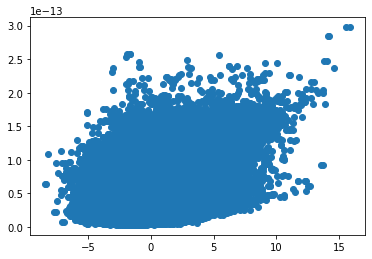

In [45]:
plt.scatter(pc_scores[:,7], all_bursts['peak_amp_base'])

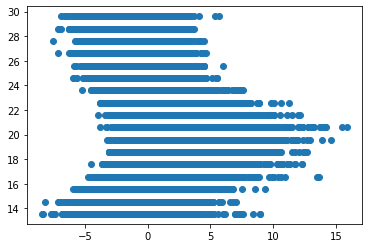

In [48]:
plt.scatter(pc_scores[:,7], all_bursts['peak_freq'])

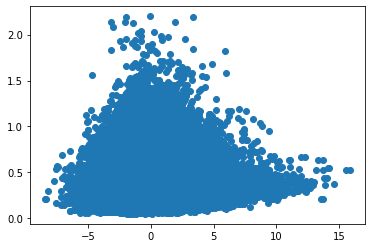

In [51]:
plt.scatter(pc_scores[:,7], all_bursts['fwhm_time'])

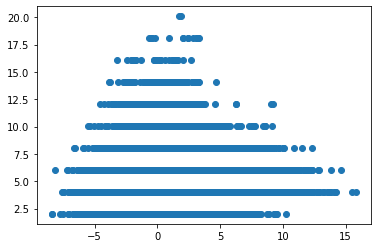

In [54]:
plt.scatter(pc_scores[:,7], all_bursts['fwhm_freq'])

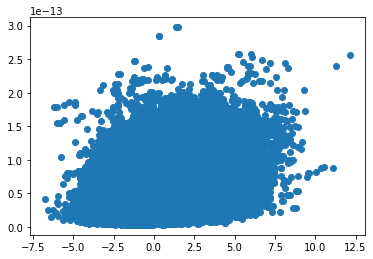

In [46]:
plt.scatter(pc_scores[:,9], all_bursts['peak_amp_base'])

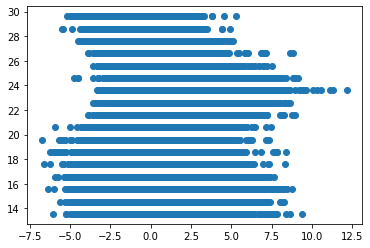

In [49]:
plt.scatter(pc_scores[:,9], all_bursts['peak_freq'])

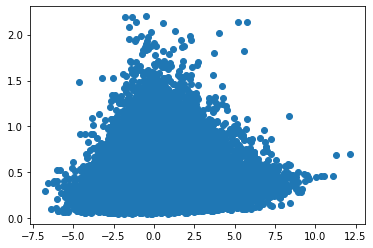

In [52]:
plt.scatter(pc_scores[:,9], all_bursts['fwhm_time'])

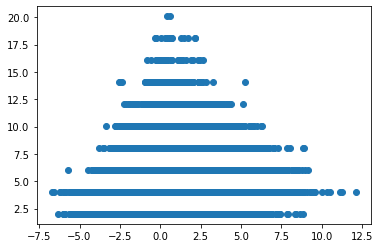

In [55]:
plt.scatter(pc_scores[:,9], all_bursts['fwhm_freq'])

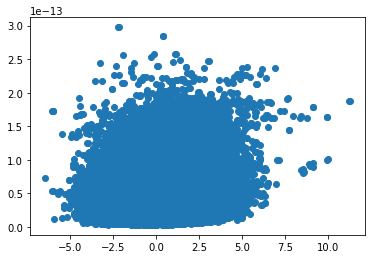

In [47]:
plt.scatter(pc_scores[:,11], all_bursts['peak_amp_base'])

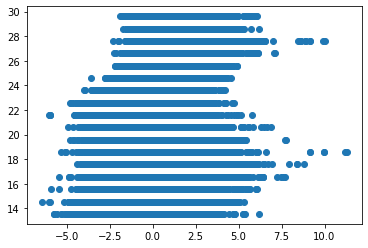

In [50]:
plt.scatter(pc_scores[:,11], all_bursts['peak_freq'])

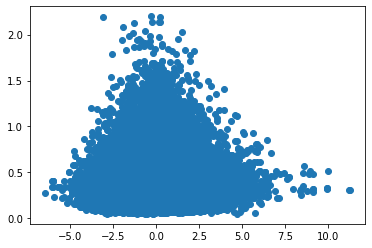

In [53]:
plt.scatter(pc_scores[:,11], all_bursts['fwhm_time'])

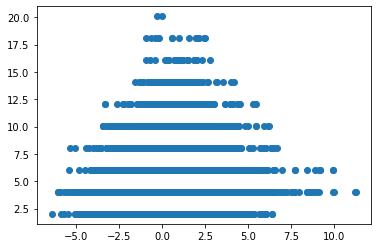

In [56]:
plt.scatter(pc_scores[:,11], all_bursts['fwhm_freq'])

Text(0, 0.5, 'PC10 score')

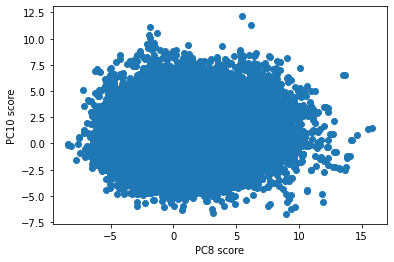

In [60]:
plt.scatter(pc_scores[:,7],pc_scores[:,9])
plt.xlabel('PC8 score')
plt.ylabel('PC10 score')

Text(0, 0.5, 'PC12 score')

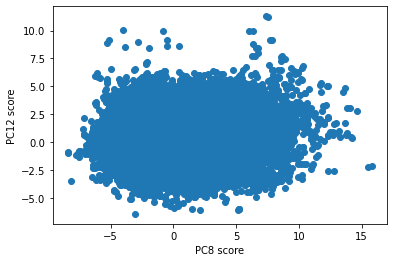

In [61]:
plt.scatter(pc_scores[:,7],pc_scores[:,11])
plt.xlabel('PC8 score')
plt.ylabel('PC12 score')

Text(0, 0.5, 'PC12 score')

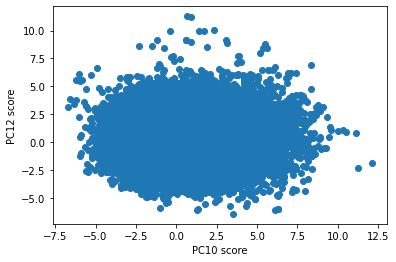

In [64]:
plt.scatter(pc_scores[:,9],pc_scores[:,11])
plt.xlabel('PC10 score')
plt.ylabel('PC12 score')